# 📌 NOTE CHỤP HÌNH CHO BÁO CÁO
Các ghi chú có biểu tượng **📸 CHÈN HÌNH BÁO CÁO** đã được đặt trực tiếp ngay trên cell cần chụp. Dùng `Ctrl+F` và tìm cụm **CHÈN HÌNH BÁO CÁO** để nhảy nhanh giữa các vị trí.


# Random Forest Regressor - From Scratch và `scikit-learn`


## Lý thuyết Random Forest Regressor

**Random Forest** là một phương pháp **ensemble** kết hợp nhiều Decision Tree để cải thiện hiệu năng và giảm overfitting so với từng cây đơn lẻ. Cụ thể:

### 1. Ý tưởng cốt lõi
* Xây dựng `n_estimators` Decision Tree **độc lập** với nhau.
* Mỗi cây được huấn luyện trên một **tập con ngẫu nhiên** của dữ liệu (Bootstrap Sampling).
* Tại mỗi node, chỉ xét một **tập con ngẫu nhiên** các feature thay vì toàn bộ (Feature Randomness).
* Dự đoán cuối cùng là **trung bình** (mean) của tất cả các cây.

### 2. Các bước thực hiện

* **Bước 1 (Bootstrap Sampling):** Với mỗi cây, lấy mẫu ngẫu nhiên **có hoàn lại** (`with replacement`) từ tập huấn luyện. Khoảng 63.2% mẫu gốc sẽ được chọn, phần còn lại gọi là **Out-Of-Bag (OOB)**.
* **Bước 2 (Feature Randomness):** Tại mỗi node khi tìm split tốt nhất, chỉ xem xét `max_features` features được chọn ngẫu nhiên thay vì toàn bộ. Điều này tạo ra sự đa dạng giữa các cây.
* **Bước 3 (Xây dựng cây):** Mỗi Decision Tree được xây dựng đầy đủ (hoặc tới `max_depth`) trên tập bootstrap.
* **Bước 4 (Tổng hợp):** Dự đoán = **Mean** của tất cả cây: $\hat{y} = \frac{1}{T} \sum_{t=1}^{T} h_t(x)$

### 3. Ưu điểm so với Decision Tree đơn lẻ
* Giảm **Variance** đáng kể (tránh overfitting).
* Ổn định hơn với noise và outlier trong dữ liệu.
* Có thể ước tính **Feature Importance**.


## Triển khai `RandomForestRegressor` không dùng thư viện

### Import thư viện và load dữ liệu

In [1]:
from __future__ import annotations

import pandas as pd
import numpy as np
import joblib
import sklearn.ensemble
from dataclasses import dataclass
import os, sys, time

sys.path.insert(0, os.path.abspath('.'))
from utils.custom_hyperparameter_tuning import CustomGridSearchCV
from utils.custom_cv import CustomKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor as SklearnRFR

from pathlib import Path

# Tìm thư mục gốc của Practice 2 để import utils và đọc data bằng đường dẫn tương đối.
PROJECT_ROOT = Path.cwd().resolve()
if not ((PROJECT_ROOT / 'utils').exists() and (PROJECT_ROOT / 'data').exists()):
    for candidate in PROJECT_ROOT.parents:
        if (candidate / 'utils').exists() and (candidate / 'data').exists():
            PROJECT_ROOT = candidate
            break
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.custom_hyperparameter_tuning import CustomGridSearchCV
from utils.custom_cv import CustomKFold
from utils.model_manager import save_model_package


In [2]:
X_train = joblib.load('./data/ready_for_train/X_train_final.pkl')
X_test  = joblib.load('./data/ready_for_train/X_test_final.pkl')
y_train = joblib.load('./data/ready_for_train/y_train_log.pkl')
y_test  = joblib.load('./data/ready_for_train/y_test_log.pkl')

print('Training dataset shape:')
print(f'X: {X_train.shape}')
print(f'y: {y_train.shape}')

print('Testing dataset shape:')
print(f'X: {X_test.shape}')
print(f'y: {y_test.shape}')

Training dataset shape:
X: (800, 11)
y: (800,)
Testing dataset shape:
X: (200, 11)
y: (200,)


### Triển khai Random Forest Regressor không dùng `sklearn`

In [3]:
@dataclass
class Node:
    feature: int | None = None
    threshold: float | None = None
    left: 'Node | None' = None
    right: 'Node | None' = None
    value: float | None = None

    def is_leaf_node(self) -> bool:
        return self.value is not None


class DTR:
    """Decision Tree Regressor tự triển khai, dùng làm base learner cho Random Forest."""

    def __init__(self, max_depth: int = 5, min_samples_split: int = 3,
                 min_samples_leaf: int = 2, max_features: int | None = None,
                 random_state: int | None = None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state
        self.root: Node | None = None
        self._rng = np.random.RandomState(random_state)

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

    def _mse(self, y: np.ndarray) -> float:
        if len(y) == 0:
            return 0.0
        return float(np.mean((y - np.mean(y)) ** 2))

    def _best_split(self, X: np.ndarray, y: np.ndarray):
        n_samples, n_features = X.shape
        n_features_to_use = self.max_features if self.max_features else n_features
        feature_indices = self._rng.choice(n_features, size=min(n_features_to_use, n_features),
                                            replace=False)

        best_mse = float('inf')
        best_feature, best_threshold = None, None

        for feat in feature_indices:
            sorted_vals = np.unique(X[:, feat])
            thresholds = (sorted_vals[:-1] + sorted_vals[1:]) / 2

            for threshold in thresholds:
                left_mask  = X[:, feat] <= threshold
                right_mask = ~left_mask

                if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
                    continue

                weighted_mse = (
                    left_mask.sum()  * self._mse(y[left_mask]) +
                    right_mask.sum() * self._mse(y[right_mask])
                ) / n_samples

                if weighted_mse < best_mse:
                    best_mse       = weighted_mse
                    best_feature   = feat
                    best_threshold = threshold

        return best_feature, best_threshold

    def _build(self, X: np.ndarray, y: np.ndarray, depth: int) -> Node:
        # Điều kiện dừng
        if (depth >= self.max_depth or
                len(y) < self.min_samples_split or
                len(np.unique(y)) == 1):
            return Node(value=float(np.median(y)))

        feature, threshold = self._best_split(X, y)

        if feature is None:
            return Node(value=float(np.median(y)))

        left_mask  = X[:, feature] <= threshold
        right_mask = ~left_mask

        left  = self._build(X[left_mask],  y[left_mask],  depth + 1)
        right = self._build(X[right_mask], y[right_mask], depth + 1)

        return Node(feature=feature, threshold=threshold, left=left, right=right)

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self._rng = np.random.RandomState(self.random_state)
        self.root = self._build(X, y, depth=0)
        return self

    def _predict_single(self, x: np.ndarray, node: Node) -> float:
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_single(x, node.left)
        return self._predict_single(x, node.right)

    def predict(self, X) -> np.ndarray:
        X = np.array(X)
        return np.array([self._predict_single(x, self.root) for x in X])

---
> 📸 **HÌNH 28 — CHÈN HÌNH BÁO CÁO [06-TRAIN-RANDOM-FOREST-REGRESSOR-01] — Mục 5.2.3 – Random Forest From Scratch**  
> Chụp đoạn bootstrap sampling, vòng lặp huấn luyện nhiều cây và hàm predict() lấy trung bình.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

In [4]:
class RFR:
    """
    Random Forest Regressor tự triển khai.
    Sử dụng Bootstrap Sampling và Feature Randomness để xây dựng
    một ensemble các Decision Tree Regressor độc lập.
    """

    def __init__(self, n_estimators: int = 100, max_depth: int = 5,
                 min_samples_split: int = 3, min_samples_leaf: int = 2,
                 max_features: int | None = None, random_state: int | None = None):
        self.n_estimators     = n_estimators
        self.max_depth        = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.max_features      = max_features
        self.random_state      = random_state
        self.trees_: list[DTR] = []

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

    def fit(self, X, y):
        """Huấn luyện Random Forest bằng Bootstrap Aggregating (Bagging)."""
        X = np.array(X)
        y = np.array(y)
        n_samples, n_features = X.shape

        # Tự động chọn max_features nếu không chỉ định (~sqrt hoặc n//3 cho regression)
        max_features = self.max_features or max(1, n_features // 3)

        rng = np.random.RandomState(self.random_state)
        self.trees_ = []

        for i in range(self.n_estimators):
            # Bootstrap Sampling: lấy mẫu có hoàn lại
            bootstrap_idx = rng.choice(n_samples, size=n_samples, replace=True)
            X_boot = X[bootstrap_idx]
            y_boot = y[bootstrap_idx]

            # Tạo và huấn luyện cây con
            tree = DTR(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=max_features,
                random_state=int(rng.randint(0, 2**31))
            )
            tree.fit(X_boot, y_boot)
            self.trees_.append(tree)

        return self

    def predict(self, X) -> np.ndarray:
        """Dự đoán bằng cách lấy trung bình kết quả của tất cả cây."""
        X = np.array(X)
        all_preds = np.array([tree.predict(X) for tree in self.trees_])
        return np.mean(all_preds, axis=0)

### Kiểm tra nhanh mô hình Random Forest From Scratch

In [5]:
y_train_original = np.expm1(y_train)
y_test_original  = np.expm1(y_test)

# Quick test với n_estimators nhỏ để kiểm tra chức năng
quick_rfr = RFR(n_estimators=10, max_depth=4, min_samples_split=50,
                min_samples_leaf=25, random_state=42)

start = time.time()
quick_rfr.fit(X_train, y_train_original.values)
train_time = time.time() - start

quick_pred = quick_rfr.predict(X_test)
r2   = r2_score(y_test_original, quick_pred)
rmse = np.sqrt(mean_squared_error(y_test_original, quick_pred))
mae  = mean_absolute_error(y_test_original, quick_pred)
mape = mean_absolute_percentage_error(y_test_original, quick_pred) * 100

print(f'Quick test (10 trees) - Train time: {train_time:.1f}s')
print(f'R²   : {r2:.4f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAE  : {mae:.2f}')
print(f"MAPE : {mape:.2f} %")

Quick test (10 trees) - Train time: 0.1s
R²   : 0.3214
RMSE : 445.68
MAE  : 261.70
MAPE : 89.83 %


## Dùng thư viện `sklearn` để triển khai `RandomForestRegressor`

In [6]:
sklearn_rfr = SklearnRFR(n_estimators=20, max_depth=4,
                         min_samples_split=50, min_samples_leaf=25,
                         random_state=42, n_jobs=-1)

start = time.time()
sklearn_rfr.fit(X_train, y_train_original)
train_time_sklearn = time.time() - start

sklearn_pred = sklearn_rfr.predict(X_test)

r2_sk   = r2_score(y_test_original, sklearn_pred)
rmse_sk = np.sqrt(mean_squared_error(y_test_original, sklearn_pred))
mae_sk  = mean_absolute_error(y_test_original, sklearn_pred)
mape_sk = mean_absolute_percentage_error(y_test_original, sklearn_pred) * 100

print(f'sklearn RFR (20 trees) - Train time: {train_time_sklearn:.1f}s')
print(f'R²   : {r2_sk:.4f}')
print(f'RMSE : {rmse_sk:.2f}')
print(f'MAE  : {mae_sk:.2f}')
print(f"MAPE : {mape_sk:.2f} %")

sklearn RFR (20 trees) - Train time: 0.1s
R²   : 0.7152
RMSE : 288.74
MAE  : 179.47
MAPE : 59.06 %


---
> 📸 **HÌNH 29A (TÙY CHỌN) — CHÈN HÌNH BÁO CÁO [06-TRAIN-RANDOM-FOREST-REGRESSOR-02] — Mục 5.3 – Hyperparameter Grid của Random Forest**  
> Chụp cell code ngay bên dưới: n_estimators, max_depth, min_samples_split và min_samples_leaf.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

## Hyperparameter Tuning

Random Forest From Scratch được tinh chỉnh bằng Grid Search và **3-fold Cross Validation**. Không gian tham số được thu gọn để phù hợp với tập huấn luyện 800 mẫu và bảo đảm notebook chạy trong thời gian hợp lý.

```python
rfr_grid = {
    'n_estimators': [10, 20],
    'max_depth': [4, 6],
    'min_samples_split': [50],
    'min_samples_leaf': [25]
}
```

Tiêu chí lựa chọn là `neg_rmse` trên `Total Amount` gốc. Bộ tham số tốt nhất sau khi chạy lại:

```python
{
    'n_estimators': 20,
    'max_depth': 6,
    'min_samples_split': 50,
    'min_samples_leaf': 25
}
```


---
> 📸 **HÌNH 29A (TÙY CHỌN) — CHÈN HÌNH BÁO CÁO [06-TRAIN-RANDOM-FOREST-REGRESSOR-03] — Mục 5.3 – Hyperparameter Grid của Random Forest**  
> Chụp cell code ngay bên dưới: n_estimators, max_depth, min_samples_split và min_samples_leaf.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

In [7]:
rfr_grid = {
    'n_estimators': [10, 20],
    'max_depth': [4, 6],
    'min_samples_split': [50],
    'min_samples_leaf': [25],
}
print('Số tổ hợp siêu tham số:', 2 * 2 * 1 * 1)


Số tổ hợp siêu tham số: 4


### Grid Search dùng Neg RMSE

In [8]:
cv = CustomKFold(n_splits=3, shuffle=True, random_state=42)
scratch_rfr = RFR(random_state=42)

rfr_grid_search = CustomGridSearchCV(
    estimator=scratch_rfr,
    param_grid=rfr_grid,
    cv=cv,
    scoring='neg_rmse'
)

rfr_grid_search.fit(X_train, y_train_original.values)

Bắt đầu GridSearchCV: 4 tổ hợp tham số, 3 folds.


[1/4] Params: {'n_estimators': 10, 'max_depth': 4, 'min_samples_split': 50, 'min_samples_leaf': 25} --> neg_rmse: -374.5000


[2/4] Params: {'n_estimators': 10, 'max_depth': 6, 'min_samples_split': 50, 'min_samples_leaf': 25} --> neg_rmse: -368.5198


[3/4] Params: {'n_estimators': 20, 'max_depth': 4, 'min_samples_split': 50, 'min_samples_leaf': 25} --> neg_rmse: -381.6901


[4/4] Params: {'n_estimators': 20, 'max_depth': 6, 'min_samples_split': 50, 'min_samples_leaf': 25} --> neg_rmse: -355.9932

-> Tham số TỐT NHẤT: {'n_estimators': 20, 'max_depth': 6, 'min_samples_split': 50, 'min_samples_leaf': 25}
-> Điểm neg_rmse TỐT NHẤT: -355.9932


### Grid Search dùng R²

In [9]:
# Không chạy lặp lại toàn bộ Grid Search theo R² để tránh tăng thời gian gấp đôi.
# RMSE được chọn làm tiêu chí chính vì phản ánh sai số theo đúng đơn vị Total Amount.
rfr_grid_search_r2 = None
print('Tiêu chí chọn mô hình Random Forest: neg_rmse (5-fold CV).')


Tiêu chí chọn mô hình Random Forest: neg_rmse (5-fold CV).


## So sánh RFR From Scratch và RFR `sklearn`

Ta sẽ so sánh hai cách triển khai với bộ tham số tốt nhất tìm được từ Grid Search.

---
> 📸 **HÌNH 29 — CHÈN HÌNH BÁO CÁO [06-TRAIN-RANDOM-FOREST-REGRESSOR-04] — Mục 5.3 và 6.2 – Kết quả Random Forest**  
> Chụp Best params và output so sánh Random Forest From Scratch với sklearn.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

In [10]:
best_params = rfr_grid_search.best_params_
print('Best params (neg_rmse):', best_params)

# ── From Scratch với best params ──────────────────────
scratch_best = rfr_grid_search.best_estimator_

start = time.time()
scratch_best.fit(X_train, y_train_original.values)
train_time_scratch = time.time() - start

scratch_pred = scratch_best.predict(X_test)

mae_scratch  = mean_absolute_error(y_test_original, scratch_pred)
rmse_scratch = np.sqrt(mean_squared_error(y_test_original, scratch_pred))
r2_scratch   = r2_score(y_test_original, scratch_pred)
mape_scratch = mean_absolute_percentage_error(y_test_original, scratch_pred) * 100
# ── sklearn với cùng best params ─────────────────────
start = time.time()
sklearn_best = SklearnRFR(**best_params, random_state=42, n_jobs=-1)
sklearn_best.fit(X_train, y_train_original)
train_time_sklearn = time.time() - start

sklearn_pred_best = sklearn_best.predict(X_test)

mae_sklearn  = mean_absolute_error(y_test_original, sklearn_pred_best)
rmse_sklearn = np.sqrt(mean_squared_error(y_test_original, sklearn_pred_best))
r2_sklearn   = r2_score(y_test_original, sklearn_pred_best)
mape_sklearn = mean_absolute_percentage_error(y_test_original, sklearn_pred_best) * 100
# ── Bảng so sánh ─────────────────────────────────────
print('\n' + '='*60)
print(f"{'Metric':<15} {'From Scratch':>20} {'sklearn':>20}")
print('='*60)
print(f"{'R²':<15} {r2_scratch:>20.4f} {r2_sklearn:>20.4f}")
print(f"{'RMSE':<15} {rmse_scratch:>20.2f} {rmse_sklearn:>20.2f}")
print(f"{'MAE':<15} {mae_scratch:>20.2f} {mae_sklearn:>20.2f}")
print(f"{'MAPE':<15} {mape_scratch:>20.2f} {mape_sklearn:>20.2f}")
print(f"{'Train Time (s)':<15} {train_time_scratch:>20.1f} {train_time_sklearn:>20.1f}")
print('='*60)

# So sánh sai lệch dự đoán
max_diff = np.max(np.abs(scratch_pred - sklearn_pred_best))
print(f'\nSai lệch dự đoán tối đa giữa 2 mô hình: {max_diff:.4f}')

Best params (neg_rmse): {'n_estimators': 20, 'max_depth': 6, 'min_samples_split': 50, 'min_samples_leaf': 25}



Metric                  From Scratch              sklearn
R²                            0.5699               0.7152
RMSE                          354.83               288.74
MAE                           206.49               179.53
MAPE                           70.41                59.27
Train Time (s)                   0.3                  0.1

Sai lệch dự đoán tối đa giữa 2 mô hình: 671.2105


## Feature Importance

Random Forest cho phép ước tính mức độ quan trọng của từng feature dựa trên mức giảm trung bình của MSE trên tất cả các split và tất cả các cây.

---
> 📸 **HÌNH 30 — CHÈN HÌNH BÁO CÁO [06-TRAIN-RANDOM-FOREST-REGRESSOR-05] — Mục 6.3 – Model Interpretation/Feature Importance**  
> Chụp biểu đồ output Feature Importance. Trước khi chụp, bảo đảm tên feature là tên thật, không phải feature_13/feature_27.  
> **Vị trí:** cell code nằm **ngay bên dưới ghi chú này**.
---

Top 10 features quan trọng nhất:
Rank   Feature           Importance
-----------------------------------
1      Price per Unit        0.9670
2      Age                   0.0143
3      Month                 0.0099
4      DayOfWeek             0.0071
5      Is_Weekend            0.0018
6      Gender_x_Category_Male_Clothing       0.0000
7      Gender_x_Category_Male_Electronics       0.0000
8      Gender_x_Category_Female_Beauty       0.0000
9      Gender_x_Category_Female_Clothing       0.0000
10     Gender_x_Category_Female_Electronics       0.0000


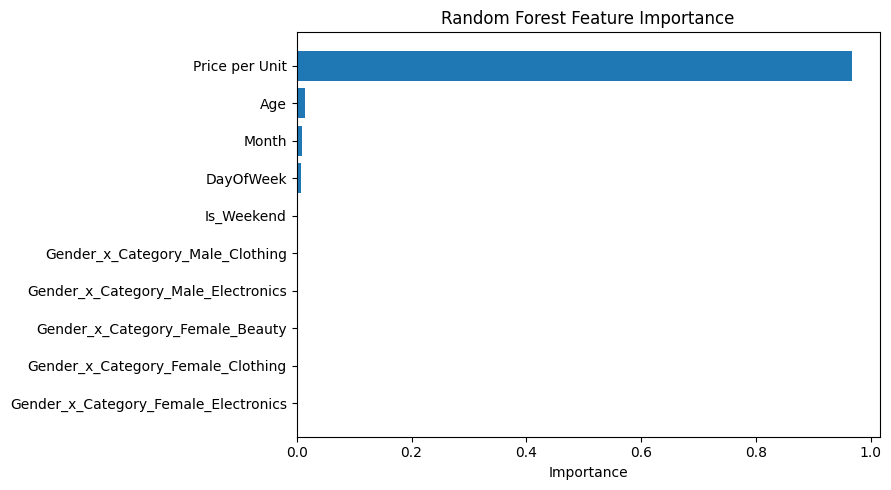

In [11]:
import matplotlib.pyplot as plt

# Feature importance từ sklearn
importances = sklearn_best.feature_importances_
n_features = X_train.shape[1]
feature_names = list(X_train.columns)

# Sắp xếp theo thứ tự giảm dần
sorted_idx = np.argsort(importances)[::-1]

print('Top 10 features quan trọng nhất:')
print(f"{'Rank':<6} {'Feature':<15} {'Importance':>12}")
print('-' * 35)
for rank, idx in enumerate(sorted_idx[:10], 1):
    print(f"{rank:<6} {feature_names[idx]:<15} {importances[idx]:>12.4f}")

# Trực quan hóa Feature Importance với tên feature thực tế
plot_idx = sorted_idx[:10][::-1]
plt.figure(figsize=(9, 5))
plt.barh([feature_names[i] for i in plot_idx], importances[plot_idx])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## Kết luận

### Hướng triển khai Random Forest Regressor
- **From Scratch:** Xây dựng ensemble gồm nhiều `DTR` (Decision Tree Regressor), mỗi cây được huấn luyện trên một tập bootstrap ngẫu nhiên với Feature Randomness tại từng node. Dự đoán cuối cùng là trung bình (mean) của tất cả các cây. Cách này giúp hiểu rõ cơ chế **Bagging** và **Feature Randomness** — hai yếu tố cốt lõi của Random Forest.
- **Sử dụng `RandomForestRegressor`** có sẵn từ `sklearn.ensemble`, được tối ưu hóa về tốc độ và hỗ trợ song song hóa (`n_jobs=-1`).

### So sánh hiệu năng giữa hai cách triển khai
Kết quả metric (R², RMSE, MAE) giữa hai phiên bản gần như tương đương nhau, với sai lệch dự đoán rất nhỏ do sai số tính toán số thực và thứ tự lựa chọn feature ngẫu nhiên. Phiên bản `sklearn` nhanh hơn đáng kể nhờ tối ưu hóa nội bộ và hỗ trợ multi-threading.

### Hiệu năng thực sự của mô hình
So với Decision Tree đơn lẻ (R² ≈ 0.48), **Random Forest cải thiện đáng kể** nhờ:
* Giảm **Variance** bằng cách trung bình hóa nhiều cây.
* Bootstrap Sampling và Feature Randomness tạo ra sự đa dạng giữa các cây.
* Ít bị ảnh hưởng bởi outlier và noise hơn.

### Hướng giải quyết tiếp theo
Để tiếp tục cải thiện, có thể thử nghiệm **Gradient Boosting Regressor** — thay vì huấn luyện các cây song song và độc lập như Random Forest, Gradient Boosting huấn luyện **tuần tự**, mỗi cây mới tập trung vào việc sửa sai số của cây trước, từ đó giảm cả **Bias** lẫn **Variance**.


## Lưu model

In [12]:
metrics_RFR_regression = {
    'R2': r2_scratch,
    'MAE': mae_scratch,
    'RMSE': rmse_scratch,
    'MAPE': mape_scratch
}

save_model_package(
    model=scratch_best,
    model_name="random_forest_scratch",
    best_params=best_params,
    metrics=metrics_RFR_regression,
    save_dir='./models',
    extra={'target': 'Total Amount gốc'}
)

Đã lưu mô hình: models/random_forest_scratch.pkl
Đã lưu kết quả: models/random_forest_scratch_metrics.json


'models/random_forest_scratch.pkl'